# Task 1 — Campus Store Sales Analytics (NumPy + pandas)

**Solution notebook.** Every code cell is commented to explain *why*, not just *what*.

Files used: `campus_store_sales.csv`, `store_inventory.csv`

In [1]:
# Imports
import pandas as pd
import numpy as np

## Part A — Load & Inspect

In [2]:
# Load the raw transactions file
df = pd.read_csv("campus_store_sales.csv")

# Quick shape/structure check
print("Shape:", df.shape)
df.head()

Shape: (601, 6)


,date,product,category,branch,units_sold,unit_price
0,2026-06-14,GEL PEN PACK,Stationery,Model Town Campus,5,78.63
1,2026-06-07,Energy Drink,Beverages,Gulberg Campus,5,159.73
2,2026-06-30,Highlighter Set,Stationery,DHA Campus,3,235.44
3,2026-06-24,Chicken Patty,Snacks,Model Town Campus,9,NaN
4,2026-06-18,Earphones Basic,Electronics,Gulberg Campus,1,355.41


In [3]:
# dtypes, non-null counts -> tells us date is still a string (object) and where nulls live
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        601 non-null    str    
 1   product     601 non-null    str    
 2   category    601 non-null    str    
 3   branch      601 non-null    str    
 4   units_sold  601 non-null    int64  
 5   unit_price  567 non-null    float64
dtypes: float64(1), int64(1), str(4)
memory usage: 28.3 KB


In [4]:
# Summary stats for numeric columns (units_sold, unit_price)
df.describe()

,units_sold,unit_price
count,601.000000,567.000000
mean,5.778702,204.278007
std,3.230987,247.031473
min,1.000000,38.180000
25%,3.000000,55.450000
50%,6.000000,124.740000
75%,9.000000,212.090000
max,11.000000,971.610000


In [5]:
# Missing values per column
print("Missing values per column:")
print(df.isna().sum())

# Exact duplicate rows (every column identical) — these are accidental double-entries
print("\nExact duplicate rows:", df.duplicated().sum())

Missing values per column:
date           0
product        0
category       0
branch         0
units_sold     0
unit_price    34
dtype: int64

Exact duplicate rows: 15


## Part B — Clean the Data

Order matters here: dedupe first, then fix text, then fill missing prices
(filling first would let duplicate rows skew the per-product average we use for filling).

In [6]:
# 1. Drop exact duplicate rows (keep the first occurrence)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} rows remain")

Dropped 15 duplicate rows -> 586 rows remain


In [7]:
# 2. Standardize the `product` column: strip stray whitespace, fix casing,
#    and collapse any double-spaces so variants collapse into one canonical label.
df["product"] = (
    df["product"]
    .str.strip()                      # remove leading/trailing spaces
    .str.replace(r"\s+", " ", regex=True)  # collapse multiple spaces into one
    .str.title()                      # consistent Title Case
)

# Sanity check: how many unique product names now vs before cleaning?
print("Unique product names after cleaning:", df["product"].nunique())
print(sorted(df["product"].unique()))

Unique product names after cleaning: 11
['Chicken Patty', 'Cold Coffee', 'Earphones Basic', 'Energy Drink', 'Gel Pen Pack', 'Highlighter Set', 'Mineral Water 500Ml', 'Notebook A4', 'Potato Chips', 'Samosa', 'Usb Flash Drive 32Gb']


In [8]:
# 3. Fill missing unit_price with the AVERAGE price of that same product
#    (not a global average — a Notebook and a USB drive have very different prices).
#    groupby(...).transform("mean") broadcasts each group's mean back to every row
#    in that group, so it lines up index-for-index with the original DataFrame.
product_avg_price = df.groupby("product")["unit_price"].transform("mean")
df["unit_price"] = df["unit_price"].fillna(product_avg_price)

# Confirm no missing prices remain
print("Remaining missing unit_price values:", df["unit_price"].isna().sum())

Remaining missing unit_price values: 0


In [9]:
# 4. Convert date to a real datetime type (currently a plain string)
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dtype)
df.head()

datetime64[us]


,date,product,category,branch,units_sold,unit_price
0,2026-06-14,Gel Pen Pack,Stationery,Model Town Campus,5,78.630000
1,2026-06-07,Energy Drink,Beverages,Gulberg Campus,5,159.730000
2,2026-06-30,Highlighter Set,Stationery,DHA Campus,3,235.440000
3,2026-06-24,Chicken Patty,Snacks,Model Town Campus,9,61.158049
4,2026-06-18,Earphones Basic,Electronics,Gulberg Campus,1,355.410000


## Part C — Feature Engineering & NumPy Aggregations

In [10]:
# Revenue per transaction = units sold x price per unit
df["revenue"] = df["units_sold"] * df["unit_price"]
df[["product", "units_sold", "unit_price", "revenue"]].head()

,product,units_sold,unit_price,revenue
0,Gel Pen Pack,5,78.630000,393.150000
1,Energy Drink,5,159.730000,798.650000
2,Highlighter Set,3,235.440000,706.320000
3,Chicken Patty,9,61.158049,550.422439
4,Earphones Basic,1,355.410000,355.410000


In [11]:
# Pull the revenue column out as a plain NumPy array so we can practice
# NumPy's own aggregation functions instead of pandas' built-in .mean()/.std()
revenue_arr = df["revenue"].to_numpy()

total_revenue   = np.sum(revenue_arr)
mean_revenue    = np.mean(revenue_arr)
std_revenue     = np.std(revenue_arr)
p90_revenue     = np.percentile(revenue_arr, 90)

print(f"Total revenue:        Rs {total_revenue:,.2f}")
print(f"Mean per transaction: Rs {mean_revenue:,.2f}")
print(f"Std deviation:        Rs {std_revenue:,.2f}")
print(f"90th percentile:      Rs {p90_revenue:,.2f}")

Total revenue:        Rs 692,372.49
Mean per transaction: Rs 1,181.52
Std deviation:        Rs 1,784.84
90th percentile:      Rs 2,548.89


In [12]:
# Boolean/fancy indexing: flag "big sale" transactions —
# anything more than 2 standard deviations above the mean.
outlier_threshold = mean_revenue + 2 * std_revenue
outlier_mask = revenue_arr > outlier_threshold   # boolean array, same length as revenue_arr

outlier_rows = df[outlier_mask]  # pandas accepts a numpy boolean mask directly
print(f"Threshold: Rs {outlier_threshold:,.2f}")
print(f"Number of outlier transactions: {len(outlier_rows)}")
outlier_rows[["date", "product", "branch", "revenue"]].sort_values("revenue", ascending=False)

Threshold: Rs 4,751.20
Number of outlier transactions: 30


,date,product,branch,revenue
58,2026-06-11,Usb Flash Drive 32Gb,DHA Campus,10534.260000
191,2026-06-17,Usb Flash Drive 32Gb,Model Town Campus,10264.100000
139,2026-06-24,Usb Flash Drive 32Gb,DHA Campus,9985.250000
575,2026-06-30,Usb Flash Drive 32Gb,Model Town Campus,9842.470000
226,2026-06-08,Usb Flash Drive 32Gb,Model Town Campus,9497.000000
10,2026-06-04,Usb Flash Drive 32Gb,Model Town Campus,9495.500000
264,2026-06-24,Usb Flash Drive 32Gb,Model Town Campus,9489.300000
380,2026-06-08,Usb Flash Drive 32Gb,Model Town Campus,9416.700000
211,2026-06-10,Usb Flash Drive 32Gb,Gulberg Campus,9282.300000
543,2026-06-28,Usb Flash Drive 32Gb,Model Town Campus,9165.100000


In [13]:
# Broadcasting: apply a different tax rate per branch WITHOUT a python for-loop.
# Step 1: map each branch name to its tax rate (a plain dict lookup, vectorized via .map)
tax_rates = {
    "Gulberg Campus": 0.05,
    "DHA Campus": 0.07,
    "Model Town Campus": 0.06,
}
rate_per_row = df["branch"].map(tax_rates).to_numpy()  # one rate per transaction, aligned by position

# Step 2: elementwise multiply — this is the "broadcasting" step: two same-shaped
# NumPy arrays multiplied position-by-position, no explicit loop needed.
net_revenue_arr = revenue_arr * (1 - rate_per_row)
df["net_revenue"] = net_revenue_arr

df[["branch", "revenue", "net_revenue"]].head()

,branch,revenue,net_revenue
0,Model Town Campus,393.150000,369.561000
1,Gulberg Campus,798.650000,758.717500
2,DHA Campus,706.320000,656.877600
3,Model Town Campus,550.422439,517.397093
4,Gulberg Campus,355.410000,337.639500


## Part D — Group Analysis

In [14]:
# Total revenue per product, highest first
revenue_by_product = (
    df.groupby("product")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
print("Top 5 products by revenue:")
revenue_by_product.head()

Top 5 products by revenue:


product
Usb Flash Drive 32Gb    300352.487500
Earphones Basic         100460.135306
Highlighter Set          56741.096667
Energy Drink             56238.771562
Cold Coffee              52989.637571
Name: revenue, dtype: float64

In [15]:
# Category x Branch revenue matrix — groupby then reshape with pivot_table
category_branch_pivot = df.pivot_table(
    values="revenue",
    index="category",
    columns="branch",
    aggfunc="sum",
)
category_branch_pivot

branch,DHA Campus,Gulberg Campus,Model Town Campus
category,,,
Beverages,43899.770000,46132.271054,31834.308733
Electronics,100010.468799,115603.618799,185198.535208
Snacks,11843.782642,13176.391358,16347.667073
Stationery,49806.446667,38178.875625,40340.350909


In [16]:
# Most frequently SOLD product by transaction count (not by revenue —
# a cheap item sold often can outrank an expensive item sold rarely).
most_frequent_product = df["product"].value_counts()
print("Top product by transaction count:")
most_frequent_product.head()

# Compare: is the top seller by count the same as the top earner by revenue?
print("\nTop by revenue:", revenue_by_product.index[0])
print("Top by transaction count:", most_frequent_product.index[0])

Top product by transaction count:

Top by revenue: Usb Flash Drive 32Gb
Top by transaction count: Cold Coffee


## Part E — Merge & Restock Check

In [17]:
# Bring in inventory data to check stock levels
inventory = pd.read_csv("store_inventory.csv")
inventory.head()

,product,category,stock_qty,reorder_level
0,Notebook A4,Stationery,43,34
1,Gel Pen Pack,Stationery,124,23
2,Highlighter Set,Stationery,97,41
3,Samosa,Snacks,157,32
4,Chicken Patty,Snacks,165,35


In [18]:
# Merge on product + category (both files share these columns)
merged = pd.merge(df, inventory, on=["product", "category"], how="left")

# Sanity check: row count should stay the same as df (a left merge on unique
# inventory rows should not duplicate any sales rows)
print("Sales rows before merge:", len(df))
print("Rows after merge:       ", len(merged))

Sales rows before merge: 586
Rows after merge:        586


In [19]:
# Boolean filter: products that need restocking (current stock below reorder level).
# Use .drop_duplicates on product so each product is only listed once, not once per sale.
needs_restock = (
    merged[merged["stock_qty"] < merged["reorder_level"]]
    [["product", "category", "stock_qty", "reorder_level"]]
    .drop_duplicates()
    .sort_values("stock_qty")
)
print(f"{len(needs_restock)} product(s) need restocking:")
needs_restock

0 product(s) need restocking:


,product,category,stock_qty,reorder_level


In [20]:
# Export the final cleaned + merged dataset
merged.to_csv("campus_store_sales_clean.csv", index=False)
print("Saved campus_store_sales_clean.csv with shape", merged.shape)

Saved campus_store_sales_clean.csv with shape (586, 10)


## Bonus Challenge

- Highest **average** revenue per transaction by branch (not just total revenue)
- Daily total revenue trend with outlier days marked

In [21]:
# Bonus 1: average revenue per transaction by branch
avg_revenue_by_branch = df.groupby("branch")["revenue"].mean().sort_values(ascending=False)
print("Average revenue per transaction by branch:")
print(avg_revenue_by_branch)

# Compare to total revenue by branch — the "best" branch can change depending on the metric!
total_revenue_by_branch = df.groupby("branch")["revenue"].sum().sort_values(ascending=False)
print("\nTotal revenue by branch:")
print(total_revenue_by_branch)

Average revenue per transaction by branch:
branch
Model Town Campus    1418.242808
Gulberg Campus       1127.466438
DHA Campus           1007.649353
Name: revenue, dtype: float64

Total revenue by branch:
branch
Model Town Campus    273720.861923
Gulberg Campus       213091.156835
DHA Campus           205560.468107
Name: revenue, dtype: float64


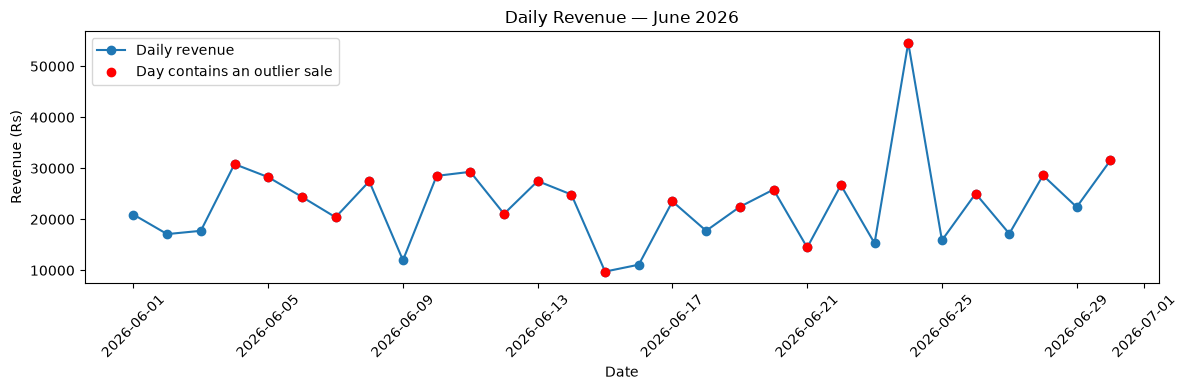

In [22]:
# Bonus 2: daily total revenue with outlier days marked
daily_revenue = df.groupby(df["date"].dt.date)["revenue"].sum()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_revenue.index, daily_revenue.values, marker="o", label="Daily revenue")

# Mark days that contain at least one outlier transaction
outlier_dates = df.loc[outlier_mask, "date"].dt.date.unique()
outlier_daily_values = daily_revenue.loc[daily_revenue.index.isin(outlier_dates)]
ax.scatter(outlier_daily_values.index, outlier_daily_values.values,
           color="red", zorder=5, label="Day contains an outlier sale")

ax.set_title("Daily Revenue — June 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (Rs)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()